## Mécanique des Milieux Continus 3
#### Université de Toulouse, 2026

Auteur: Christophe.Airiau@utoulouse.fr

<table style="width: 100%">
    <colgroup>
       <col span="1" style="width: 40%;">
       <col span="1" style="width: 20%;">
       <col span="1" style="width: 45%;">
    </colgroup>
    <tbody>
        <tr>
            <td style="background-color: #ffffff"><img src="Figures/ut_2025.png" width="200"></td>
            <td style="background-color: #ffffff"> </td>
            <td style="background-color: #ffffff"> 
            Licence de Mécanique-énergétique, MMC3
            </td>
        </tr>
    </tbody>
</table>

# **<span style="color:orange">Contrainte linéaire plane sur une plaque </span>**
# **<span style="color:blue"> Application d'une fonction de contrainte </span>**

## Introduction, configuration

Elle est définie par:

$$ \large
\Phi(x, y) =  \dfrac a  6  x^3 + \dfrac b 6  y^3 - \dfrac c 2   x^2  y - \dfrac d 2   x   y^2 
$$

Cette fonction correspond à ce problème de contraintes planes :

<img src="Figures/plaque_plane.png" width="500">

On va dans l'ordre :

1. calculer les contraintes
2. déterminer le chargement local sur les bords
3. déterminer l'effort normal et tangentiel sur chaque bord
4. vérifier l'équilibre global
5. proposer des graphiques 

In [1]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sympy import latex, lambdify
from sympy.interactive import init_printing
import sympy.printing as printing
from IPython.display import display, Latex
init_printing()
%matplotlib inline
#%matplotlib notebook
# matplotlib widget
# Graphical options
style_list =  plt.style.available
print(style_list)
plt.style.use(style_list[0])
plt.rcParams["image.cmap"] = "RdYlBu_r"

def print_(var, value):
    result = "$${} \qquad : \qquad {}$$".format(var, latex(value))
    display(Latex(result))
    
def printn_(var, value):
    for v, val in zip(var, value):
        result = "$${} \qquad : \qquad {}$$".format(v, latex(val))
        display(Latex(result))

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
# Variable definition
x, y = symbols('x y')             # coordinates
a, b , c, d = symbols('a b c d')  # stress parameters
L, h =  symbols("L h")            # plate dimensions

## Données pour les applications numériques

In [3]:
a_num, b_num, c_num, d_num = 1, 1, 1, 1
L_num, b_num = 1, 0.04
s_num = {a: a_num, b: b_num, c: c_num, d: d_num, L: L_num, h: b_num}
npt = 41
x_num = np.linspace(0, L_num, npt)
y_num = np.linspace(-b_num/2, b_num/2, npt)
x_vec, y_vec = np.meshgrid(x_num, y_num)

In [4]:
# Airy function:
phi = a / 6 * x**3 + b / 6 * y**3 - c/2 * x**2 * y - d/2 * x * y**2 

## Fonction du calcul des contraintes
$$ \Large
\sigma_{xx} = \dfrac{\partial^2 \Phi}{\partial^2 x}, \qquad 
\sigma_{yy} = \dfrac{\partial^2 \Phi}{\partial^2 y}, \qquad
\sigma_{xy} = -~\dfrac{\partial^2 \Phi}{\partial x \partial y}
$$

In [5]:
def airy_stress(phi, x, y):
    """
    Return stresses from the Airy stress function: sigma_{xx}, sigma_{yy}, sigma_{xy}
    The coordinate system is Cartesian
    """
    return diff(phi, y, 2), diff(phi, x, 2), -diff(phi, y, 1, x, 1)


# **<span style="color:red">1.  Vérification que la fonction est bi-harmonique</span>**

In [6]:
lap = diff(phi, y, 2) + diff(phi, x, 2)
lap2 = diff(lap, y, 2) + diff(lap, x, 2)
eq = diff(phi, y, 4) + diff(phi, x, 4)+ 2 * diff(phi, y, 2, x, 2)
print_("\Delta\Delta \Phi", eq)
print_("\Delta\Delta \Phi", lap2)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# **<span style="color:red">2.  Calcul des contraintes </span>**

$$\sigma_{xx} = \dfrac{\partial^2\Phi}{\partial y^2}, \qquad 
\sigma_{yy} = \dfrac{\partial^2\Phi}{\partial x^2}, \qquad
\sigma_{xy} = - \dfrac{\partial^2\Phi}{\partial x \partial y}
$$

In [7]:
sxx, syy, sxy = airy_stress(phi, x, y)

# **<span style="color:red">3. Affichage des contraintes</span>**

In [8]:
printn_(("\sigma_{xx}", "\sigma_{yy}", "\sigma_{xy}" ), (sxx, syy, sxy))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# **<span style="color:red">4. Calcul des contraintes sur les bords</span>**

$$ \Large
\vec T = T_x~\vec e_x + T_y~\vec e_y = \bar{\bar\sigma}~\vec n
$$

# **<span style="color:orange">4.1 extrémités x = 0 et  x= L </span>**

## $x = 0, \vec n = -\vec e_x$

In [9]:
T_x = -sxx.subs(x, 0)
T_y= -sxy.subs(x, 0)
printn_(("T_x", "T_y"), (T_x, T_y))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

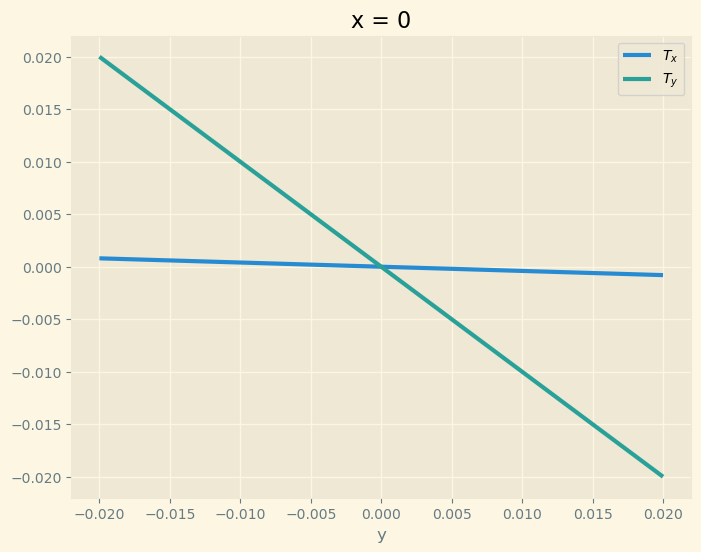

In [10]:

def plot_stress(s_num, tx, ty, fig=0,  title="x = 0", xlabel="y"):
    """
    graphics to plot stress on a boundary
    s_num : x or y
    tx, ty : T_x, T_y
    """
    plt.figure(figsize=(8, 6))
    plt.plot(s_num, tx(s_num), lw=3, label="$T_x$")
    plt.plot(s_num, ty(s_num), lw=3, label="$T_y$")
    plt.xlabel(xlabel)
    plt.title(title)
    plt.legend()

Tx_fun = lambdify(y, T_x.subs(b, b_num), "numpy")
Ty_fun = lambdify(y, T_y.subs(d, d_num), "numpy")
plot_stress(y_num, Tx_fun, Ty_fun, fig=0, title="x = 0", xlabel="y")
plt.show()

## $x=L, \vec n= \vec e_x$

In [11]:
T_x = sxx.subs(x, L)
T_y = sxy.subs(x, L)
printn_(("T_x", "T_y"), (T_x, T_y))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [12]:
# T_x.subs({d:d_num, L:L_num})

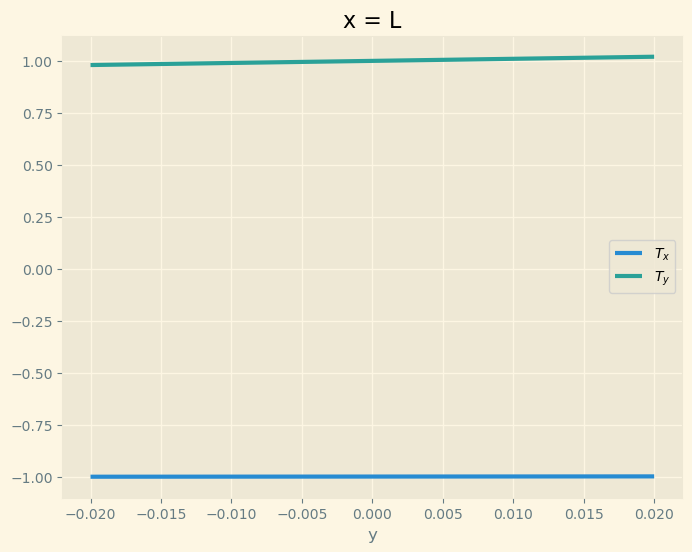

In [13]:
Tx_fun = lambdify(y, T_x.subs(s_num), "numpy")
Ty_fun = lambdify(y, T_y.subs(s_num), "numpy")
plot_stress(y_num, Tx_fun, Ty_fun,fig=1, title="x = L", xlabel="y")
plt.show()

## effort globaux x=0 et x=L

On intègre dans une section de normale $\vec n = \vec e_x$

$$ \displaystyle \large 
\displaystyle X = \int_{-b/2}^{b/2} \sigma_{xx} dy, \qquad Y = \int_{-b/2}^{b/2} \sigma_{xy} dy
$$

In [14]:
# quelque soit x
X = integrate(sxx, (y, -h/2, h/2))
Y = integrate(sxy, (y, -h/2, h/2))
printn_(("X", "Y"), (X, Y))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [15]:
Y0 = -Y.subs(x, 0) # le signe est pour la direction de la normale
YL = Y.subs(x, L)
X0 = -X.subs(x, 0)
XL = X.subs(x, L)
printn_(("X_0", "Y_0"), (X0, Y0))
printn_(("X_L", "Y_L"), (XL, YL))
 

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Les forces calculées ici sont sur la section $x = 0$ et $x = L$.


# **<span style="color:orange">4.2 Haut et bas (h/2, - h/2 ) </span>**


La normale à la section est suivant $\vec e_y$

##  Efforts globaux
$$ \large 
\displaystyle X = \int_0^L \sigma_{xy}~dx, \qquad Y = \int_0^L \sigma_{yy}~dx,
$$

In [16]:
Y = integrate(syy, (x, 0, L))
X = integrate(sxy, (x, 0, L))
printn_(("X", "Y"), (X, Y))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [17]:
Yhaut = Y.subs(y,h/2)
Ybas = -Y.subs(y,-h/2)  #  signe à cause de la normale
printn_(("Y_{haut}", "Y_{bas}"), (Yhaut, Ybas))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [26]:
Xhaut = X.subs(y,h/2)
Xbas = -X.subs(y,-h/2)
printn_(("X_{haut}", "X_{bas}"), (Xhaut, Xbas))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## contraintes
### y = h/2 

In [18]:
T_y = syy.subs(y, h/2)
T_x = sxy.subs(y, h/2)
printn_(("T_x", "T_y"), (T_x, T_y))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

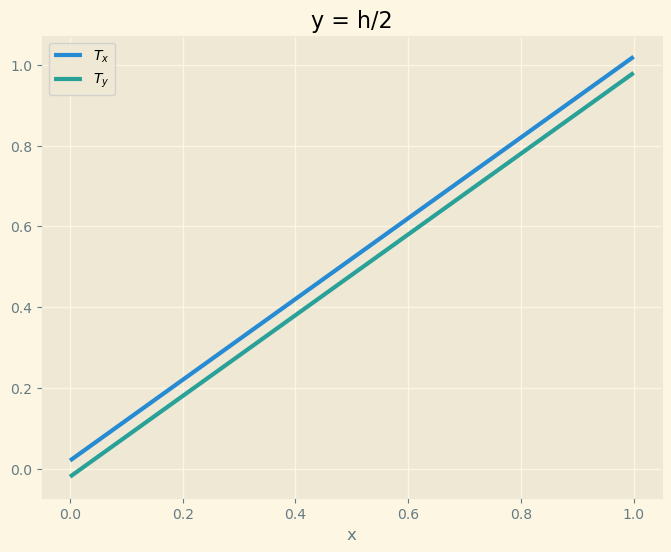

In [20]:
Tx_fun = lambdify(x, T_x.subs(s_num), "numpy")
Ty_fun = lambdify(x, T_y.subs(s_num), "numpy")
plot_stress(x_num, Tx_fun, Ty_fun, fig=2, title="y = h/2", xlabel="x")
plt.show()

## y= -h/2

In [21]:
T_y = -syy.subs(y, -h/2)
T_x = -sxy.subs(y, -h/2)
printn_(("T_x", "T_y"), (T_x, T_y))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

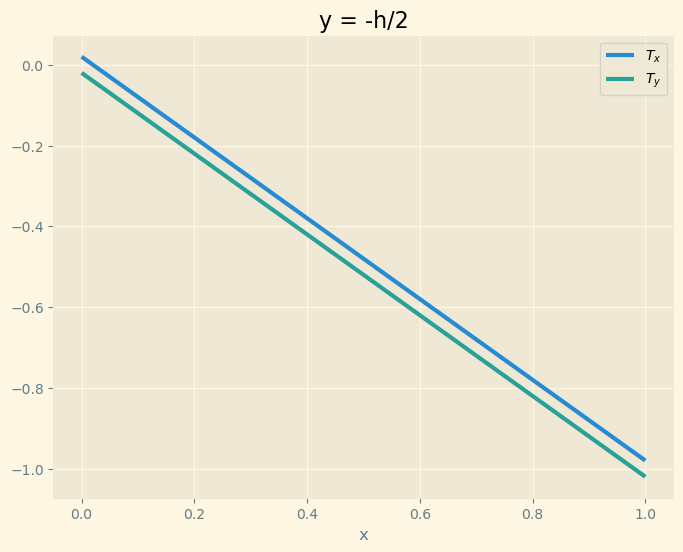

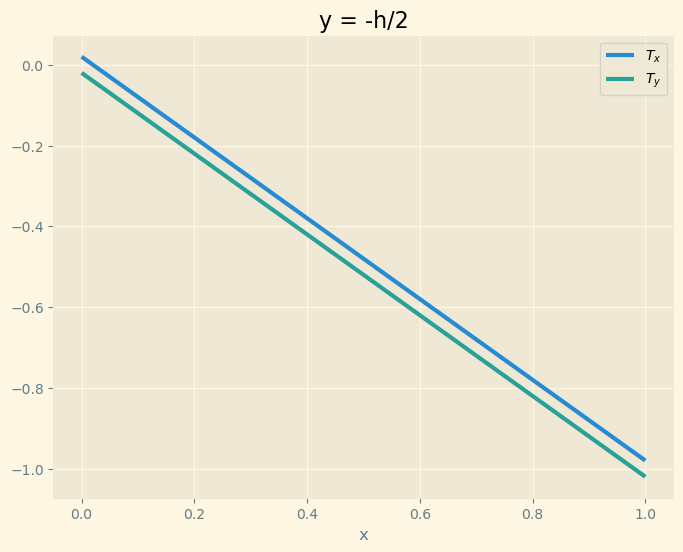

In [23]:
Tx_fun = lambdify(x, T_x.subs(s_num), "numpy")
Ty_fun = lambdify(x, T_y.subs(s_num), "numpy")
plot_stress(x_num, Tx_fun, Ty_fun, fig=3, title="y = -h/2", xlabel="x")
plt.show()

# **<span style="color:red">5. Equilibre global</span>**

Somme des forces suivant $x$ :

In [27]:
display(simplify(Xhaut + XL + X0 + Xbas))

Somme des forces suivant $y$ :

In [25]:
simplify(Yhaut + YL + Y0 + Ybas)

## Graphiques des contraintes

In [26]:
def plot_contours(x_coord, y_coord, field, fignum=None, figsize=(8, 6), lines=True, title="title"):
    """
    Plot the contours for any solution
    """
    if fignum is None:
        fig = plt.figure(figsize=figsize)
    else:
        fig = plt.figure(fignum, igsize=figsize)
    f_max = max(np.max(field), -np.min(field))
    plt.contourf(x_coord, y_coord, field, vmin=-f_max, vmax=f_max)
    plt.colorbar()
    plt.title(title)
    if lines:
        plt.contour(x_coord, y_coord, field, colors="k")
    plt.axis("image")
    return fig

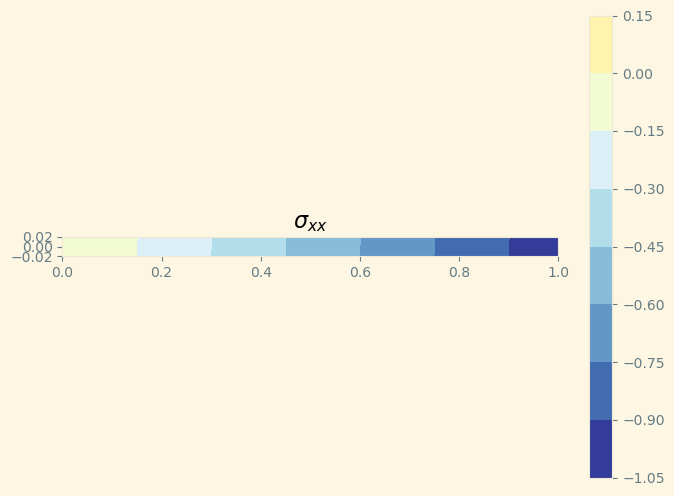

In [34]:
sxx_fun = lambdify((x, y), sxx.subs(s_num), "numpy")
#display(sxx)
plot_contours(x_vec, y_vec, sxx_fun(x_vec, y_vec), lines=False, title=r"$\sigma_{xx}$")

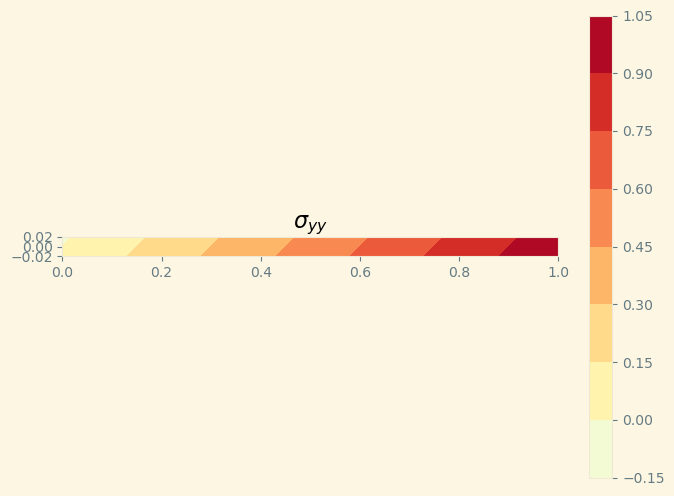

In [33]:
syy_fun = lambdify((x, y), syy.subs(s_num), "numpy")
plot_contours(x_vec, y_vec, syy_fun(x_vec, y_vec), lines=False, title=r"$\sigma_{yy}$")

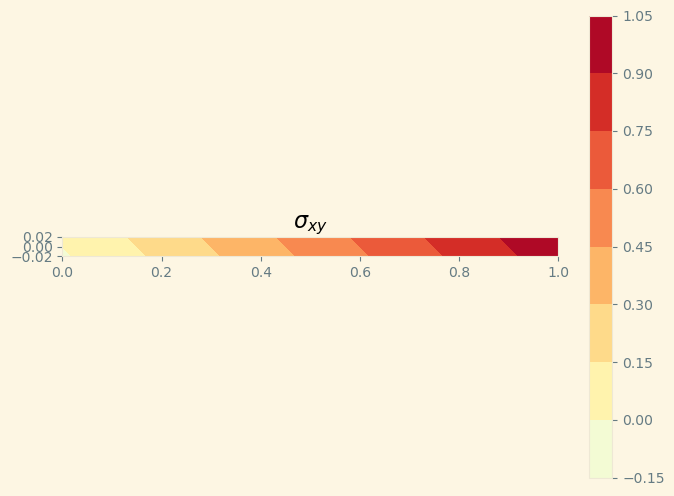

In [35]:
sxy_fun = lambdify((x, y), sxy.subs(s_num), "numpy")
plot_contours(x_vec, y_vec, sxy_fun(x_vec, y_vec), lines=False, title=r"$\sigma_{xy}$")